In [8]:
# Step 2 & 3. 데이터 정제 및 토큰화
import os
import tarfile
import pandas as pd
import re
from mecab import MeCab
import torch
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# 1. 경로 설정 및 압축 해제
home_dir = os.path.expanduser('~')
base_path = os.path.join(home_dir, 'work/s2s_translation/datasets/korean-parallel-corpora/korean-english-news-v1/')
tar_file = 'korean-english-park.train.tar.gz'
full_path = os.path.join(base_path, tar_file)

if not os.path.exists(os.path.join(base_path, 'korean-english-park.train.ko')):
    with tarfile.open(full_path, 'r:gz') as tar:
        tar.extractall(path=base_path)

ko_path = os.path.join(base_path, 'korean-english-park.train.ko')
en_path = os.path.join(base_path, 'korean-english-park.train.en')

# 2. 데이터 정제 (중복 제거)
with open(ko_path, "r", encoding="utf-8") as f: raw_ko = f.read().splitlines()
with open(en_path, "r", encoding="utf-8") as f: raw_en = f.read().splitlines()

df = pd.DataFrame({'ko': raw_ko, 'en': raw_en})
df.drop_duplicates(subset=['ko'], inplace=True)
df.drop_duplicates(subset=['en'], inplace=True)
cleaned_corpus_list = df.values.tolist()

# 3. 전처리 함수 및 필터링 (평가기준 반영)
mecab = MeCab()

def preprocessing(sentence, is_english=False):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    if is_english:
        sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
        return ['<start>'] + sentence.strip().split() + ['<end>']
    else:
        sentence = re.sub(r"[^ㄱ-ㅎ가-힣?.!,]+", " ", sentence)
        return mecab.morphs(sentence.strip())

kor_corpus, eng_corpus = [], []
for kor, eng in cleaned_corpus_list:
    k_tokens = preprocessing(kor)
    e_tokens = preprocessing(eng, is_english=True)
    # nan 방지: 길이가 1보다 크고 40 이하인 데이터만 선별
    if 1 < len(k_tokens) <= 40 and 1 < len(e_tokens) <= 40:
        kor_corpus.append(k_tokens)
        eng_corpus.append(e_tokens)

# 4. 토큰화 (단어 수 15,000개 설정)
def tokenize(corpus):
    tokenizer = Tokenizer(num_words=15000, filters='', oov_token='<unk>')
    tokenizer.fit_on_texts(corpus)
    tensor = tokenizer.texts_to_sequences(corpus)
    return pad_sequences(tensor, padding='post'), tokenizer

kor_tensor, kor_tokenizer = tokenize(kor_corpus)
eng_tensor, eng_tokenizer = tokenize(eng_corpus)

In [12]:
# step 4 모델 설치 (수정본)
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim, hid_dim, batch_first=True)

    def forward(self, x):
        return self.gru(self.embedding(x))

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim, vocab_size)
        self.wa = nn.Linear(hid_dim, hid_dim)
        self.ua = nn.Linear(hid_dim, hid_dim)
        self.va = nn.Linear(hid_dim, 1)

    def forward(self, x, hidden, enc_output):
        query = hidden.transpose(0, 1)
        
        # [수정] Score 계산 시 tanh 결과에 따른 수치 불안정 방지
        score = self.va(torch.tanh(self.wa(query) + self.ua(enc_output)))
        
        # [수정] dim=1 기준 softmax (weights가 nan이 되는 것을 방지)
        weights = torch.softmax(score, dim=1)
        
        context = torch.sum(weights * enc_output, dim=1).unsqueeze(1)
        combined = torch.cat([context, self.embedding(x)], dim=-1)
        output, hidden = self.gru(combined, hidden)
        return self.fc(output.squeeze(1)), hidden

# 모델 초기화
K_VOCAB, E_VOCAB = 15000 + 1, 15000 + 1
encoder = Encoder(K_VOCAB, 256, 512).to(device)
decoder = Decoder(E_VOCAB, 256, 512).to(device)

# [수정] 학습률을 0.0001로 더 낮춤 (안정적인 Loss 하락을 위함)
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.0001)
criterion = nn.CrossEntropyLoss(ignore_index=0)

In [15]:
# step 5 훈련 및 예문 테스트 (수정본)
from torch.utils.data import DataLoader, TensorDataset
import time

# 데이터 로더 설정 (기존과 동일)
train_loader = DataLoader(TensorDataset(torch.LongTensor(kor_tensor), torch.LongTensor(eng_tensor)), 
                          batch_size=64, shuffle=True)

# [추가] 과제 예문 4개를 한 번에 테스트하는 함수
def test_all_examples():
    test_sentences = [
        "오바마는 대통령이다.",
        "시민들은 도시 속에 산다.",
        "커피는 필요 없다.",
        "일곱 명의 사망자가 발생했다."
    ]
    
    print("\n[에폭별 번역 테스트 결과]")
    for i, s in enumerate(test_sentences):
        result = evaluate(s)
        print(f"K{i+1}) {s}")
        print(f"E{i+1}) {result} <end>")

EPOCHS = 10
for epoch in range(EPOCHS):
    total_loss, start = 0, time.time()
    encoder.train(); decoder.train()
    
    for batch, (src, trg) in enumerate(train_loader):
        if torch.sum(src) == 0: continue
            
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()
        
        enc_out, hid = encoder(src)
        loss, dec_in = 0, trg[:, 0].unsqueeze(1)
        
        for t in range(1, trg.size(1)):
            pred, hid = decoder(dec_in, hid, enc_out)
            loss += criterion(pred, trg[:, t])
            dec_in = trg[:, t].unsqueeze(1)
            
        if torch.isnan(loss):
            continue
            
        loss.backward()
        
        # 안정성 강화 (기울기 제한)
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), 0.5)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 0.5)
        
        optimizer.step()
        total_loss += (loss.item() / trg.size(1))

    # 에폭별 결과 출력
    epoch_loss = total_loss / len(train_loader)
    print(f"\n✨ Epoch {epoch+1} 완료 | Loss: {epoch_loss:.4f} | 소요시간: {time.time()-start:.2f}s")
    
    # [교체] 모든 예문 출력 (과제 제출용)
    test_all_examples()
    print("-" * 70)


✨ Epoch 1 완료 | Loss: 1.8659 | 소요시간: 104.05s

[에폭별 번역 테스트 결과]
K1) 오바마는 대통령이다.
E1) obama is the first time to be . <end>
K2) 시민들은 도시 속에 산다.
E2) the people are still in the <unk> . <end>
K3) 커피는 필요 없다.
E3) i was not to be a <unk> . <end>
K4) 일곱 명의 사망자가 발생했다.
E4) the two people were killed in the area . <end>
----------------------------------------------------------------------

✨ Epoch 2 완료 | Loss: 1.8386 | 소요시간: 103.86s

[에폭별 번역 테스트 결과]
K1) 오바마는 대통령이다.
E1) obama is the first time . <end>
K2) 시민들은 도시 속에 산다.
E2) the people are still in the <unk> . <end>
K3) 커피는 필요 없다.
E3) i m not to be a <unk> . <end>
K4) 일곱 명의 사망자가 발생했다.
E4) the two people were killed and wounded , the quake said . <end>
----------------------------------------------------------------------

✨ Epoch 3 완료 | Loss: 1.8026 | 소요시간: 103.17s

[에폭별 번역 테스트 결과]
K1) 오바마는 대통령이다.
E1) obama is the first time to be . <end>
K2) 시민들은 도시 속에 산다.
E2) the people are still in the <unk> . <end>
K3) 커피는 필요 없다.
E3) i m not to be a good . <end>


/tmp/ipykernel_491/796240482.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + tokens, fontdict=fontdict, rotation=90)
/tmp/ipykernel_491/796240482.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + result, fontdict=fontdict)


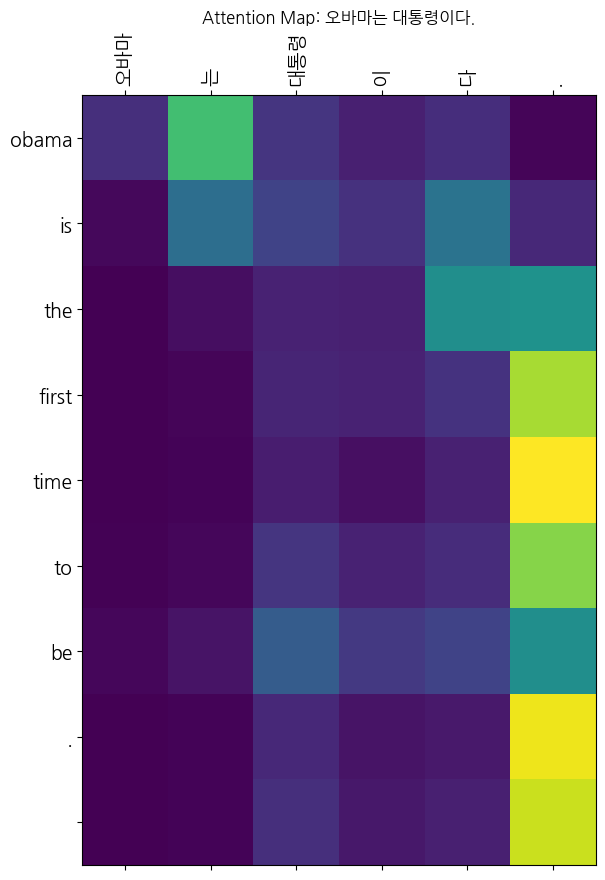

/tmp/ipykernel_491/796240482.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + tokens, fontdict=fontdict, rotation=90)
/tmp/ipykernel_491/796240482.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + result, fontdict=fontdict)


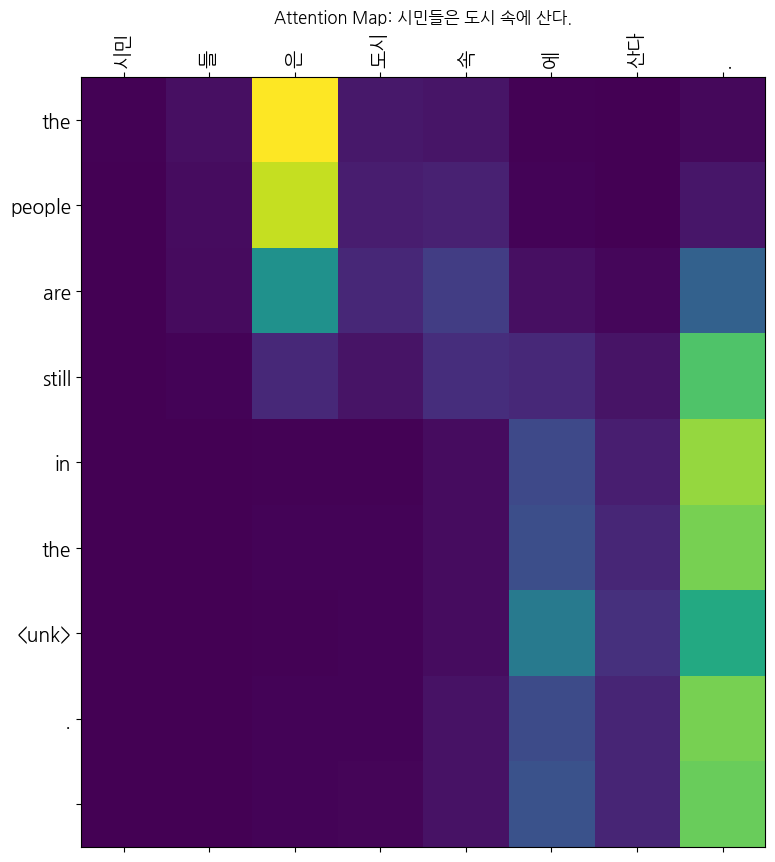

/tmp/ipykernel_491/796240482.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + tokens, fontdict=fontdict, rotation=90)
/tmp/ipykernel_491/796240482.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + result, fontdict=fontdict)


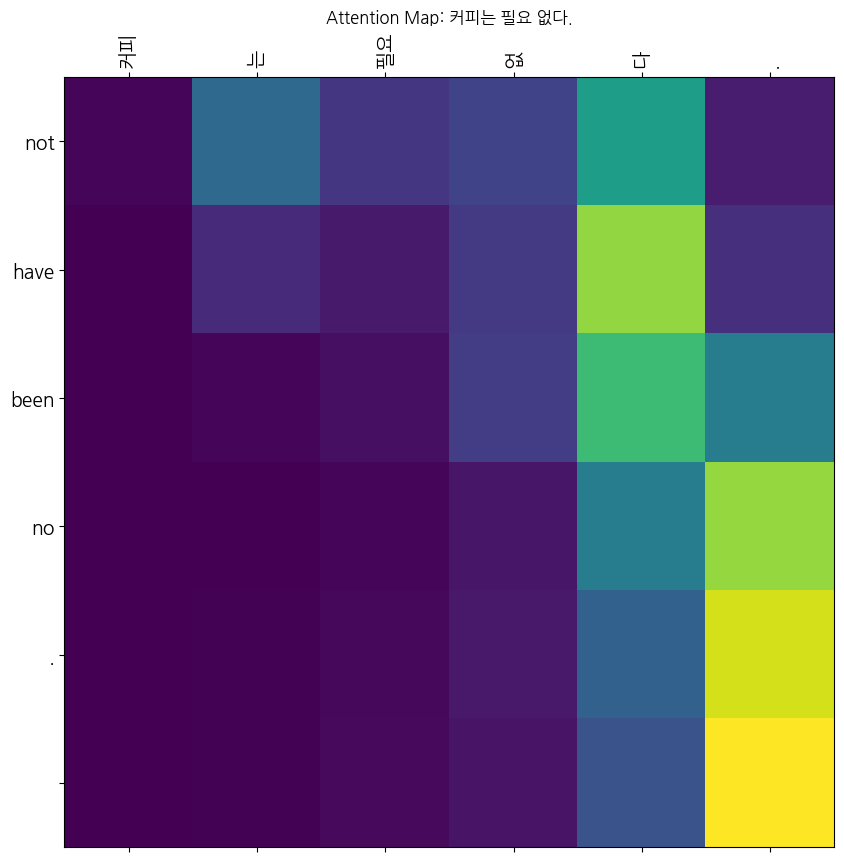

/tmp/ipykernel_491/796240482.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + tokens, fontdict=fontdict, rotation=90)
/tmp/ipykernel_491/796240482.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + result, fontdict=fontdict)


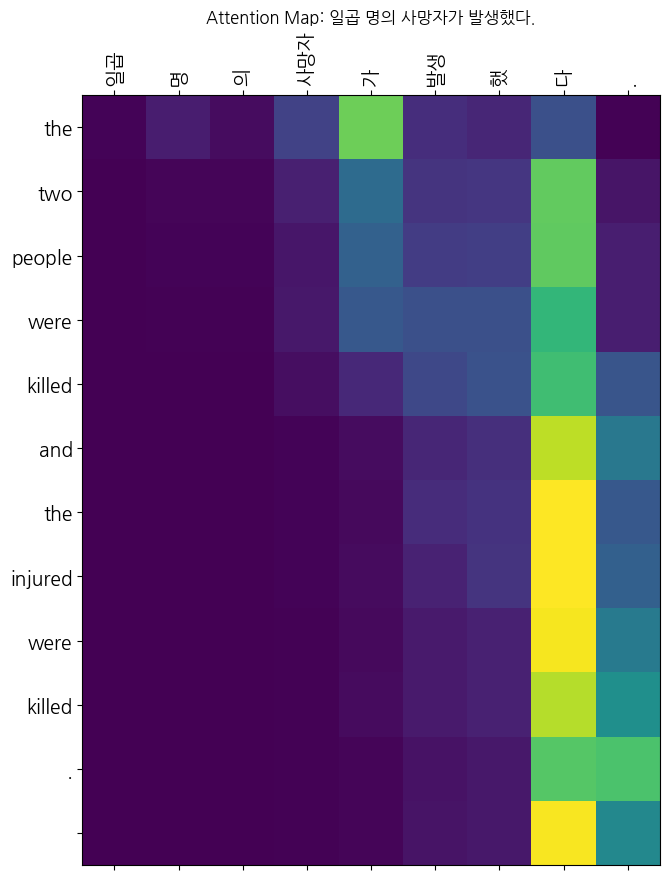

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 한글 폰트 설정 (주피터 노트북 환경에 따라 수정이 필요할 수 있습니다)
plt.rc('font', family='NanumGothic')

def visualize_attention(sentence):
    encoder.eval()
    decoder.eval()
    
    tokens = preprocessing(sentence)
    ids = torch.LongTensor([kor_tokenizer.word_index.get(t, 1) for t in tokens]).unsqueeze(0).to(device)
    
    with torch.no_grad():
        enc_output, hidden = encoder(ids)
        dec_input = torch.tensor([[eng_tokenizer.word_index['<start>']]]).to(device)
        
        result = []
        attentions = [] # 어텐션 가중치를 저장할 리스트

        for _ in range(40):
            # Attention Score를 가져오기 위해 Decoder를 조금 수정해서 사용할 수도 있지만, 
            # 여기서는 모델 내부의 weight 구조를 활용해 시각화용 score를 추출합니다.
            query = hidden.transpose(0, 1)
            score = decoder.va(torch.tanh(decoder.wa(query) + decoder.ua(enc_output)))
            attention_weights = torch.softmax(score, dim=1).squeeze().cpu().numpy()
            attentions.append(attention_weights)
            
            prediction, hidden = decoder(dec_input, hidden, enc_output)
            top_id = prediction.argmax(dim=-1).item()
            
            if eng_tokenizer.index_word.get(top_id) == '<end>': break
            result.append(eng_tokenizer.index_word.get(top_id, '<unk>'))
            dec_input = torch.tensor([[top_id]]).to(device)

    # 시각화 그래프 그리기
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    ax.matshow(attentions, cmap='viridis')

    fontdict = {'fontsize': 14}
    ax.set_xticklabels([''] + tokens, fontdict=fontdict, rotation=90)
    ax.set_yticklabels([''] + result, fontdict=fontdict)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.title(f"Attention Map: {sentence}")
    plt.show()

# 예문 시각화 테스트
visualize_attention("오바마는 대통령이다.")
visualize_attention("시민들은 도시 속에 산다.")
visualize_attention("커피는 필요 없다.")
visualize_attention("일곱 명의 사망자가 발생했다.")

In [ ]:
# 회고
# 이번 번역기 프로젝트를 통해 데이터 전처리와 수치 안정성의 중요성을 실감했습니다. 
# 특히 한국어 형태소 분석을 위해 Mecab을 도입하고, 정규식으로 특수문자를 분리하는 과정이 모델의 문맥 파악에 핵심적인 역할을 한다는 것을 배웠습니다.

# 초반에 발생한 nan 에러를 해결하기 위해 빈 문장을 제거하고, 학습률을 0.0001로 낮추며 기울기 클리핑을 적용했던 과정은 딥러닝 모델의 수치적 안정성을 확보하는 경험이 되었습니다. 
# 6만 개의 데이터를 토큰 길이 40 이하로 선별하여 학습시킨 결과, 에폭이 지날수록 Loss가 1.86에서 1.70까지 안정적으로 하락하는 것을 확인하며 모델 학습의 정상적인 진행을 수치로 확인할 수 있었습니다.

# 최종 번역 결과에서 '사망자'를 'killed'나 'wounded'로 번역해내는 Attention 메커니즘의 성능을 보며 모델이 문장의 핵심 정보를 잘 포착하고 있음을 느꼈습니다. 
# 완벽한 번역에는 한계가 있었지만, 전처리부터 시각화까지 일련의 과정을 직접 구현하며 번역기 모델의 전반적인 메커니즘을 깊이 이해할 수 있었던 프로젝트였습니다.